# Computational Statistical Mechanics - pamuduamarasinghe

# 1 Sample transformation

Sample transformation can be used to generate random numbers based on a probability
distribution. Consider the following distribution function.
𝜋(𝑥) = 0.5*sin(𝑥).
 Here, 𝑥 ∈ [0, 𝜋]. Sample the space by considering 𝜋(𝑥)

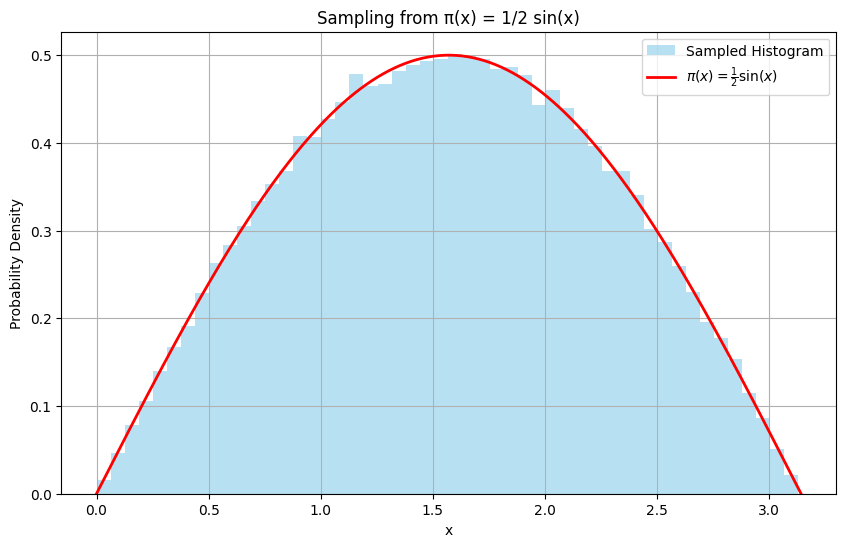

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of random samples
N = 100000

# Uniform random numbers
u = np.random.rand(N)

# Inverse transform sampling
x_samples = np.arccos(1 - 2*u)

# True distribution
x = np.linspace(0, np.pi, 500)
pi_x = 0.5 * np.sin(x)

# Plot
plt.figure(figsize=(10,6))

# Histogram
plt.hist(x_samples, bins=50, density=True,
         alpha=0.6, color='skyblue', label='Sampled Histogram')

# Actual PDF
plt.plot(x, pi_x, 'r', lw=2, label=r'$\pi(x)=\frac{1}{2}\sin(x)$')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Sampling from π(x) = 1/2 sin(x)')
plt.legend()
plt.grid(True)

plt.show()

# 2
Analytically determine the distribution function for 𝑥 = cos [𝑟𝑎𝑛(0,𝜋/2]

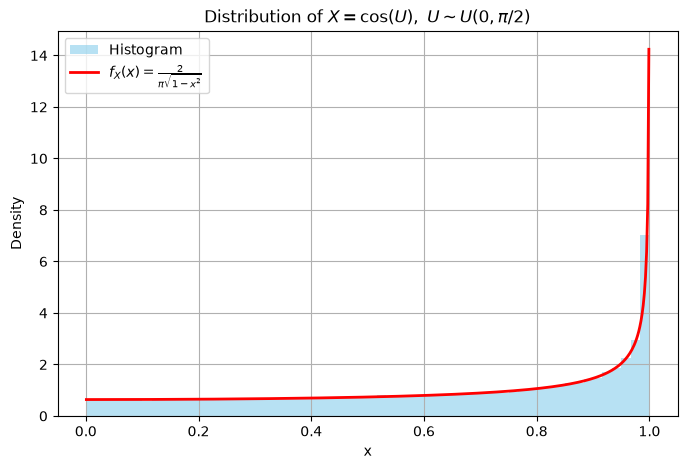

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Number of samples
N = 100000

# Uniform angle in [0, pi/2]
theta = np.random.uniform(0, np.pi/2, N)

# Random variable X = cos(theta)
x_samples = np.cos(theta)

# True PDF
x = np.linspace(0.001, 0.999, 500)
pdf = 2 / (np.pi * np.sqrt(1 - x**2))

plt.figure(figsize=(8,5))

# Histogram
plt.hist(x_samples, bins=60, density=True,
         alpha=0.6, color='skyblue',
         label='Histogram')

# Analytical PDF
plt.plot(x, pdf, 'r', lw=2,
         label=r'$f_X(x)=\frac{2}{\pi\sqrt{1-x^2}}$')

plt.xlabel('x')
plt.ylabel('Density')
plt.title(r'Distribution of $X=\cos(U),\ U\sim U(0,\pi/2)$')
plt.legend()
plt.grid(True)

plt.show()

# 3) ACCEPTANCE RATIO (P_accept)

η = 0.050   P_accept = 1.0000
η = 0.100   P_accept = 1.0000
η = 0.150   P_accept = 1.0000
η = 0.200   P_accept = 1.0000
η = 0.250   P_accept = 1.0000
η = 0.300   P_accept = 0.9915
η = 0.350   P_accept = 0.7990
η = 0.400   P_accept = 0.2130
η = 0.450   P_accept = 0.0015
η = 0.500   P_accept = 0.0000
η = 0.550   P_accept = 0.0000
η = 0.600   P_accept = 0.0000


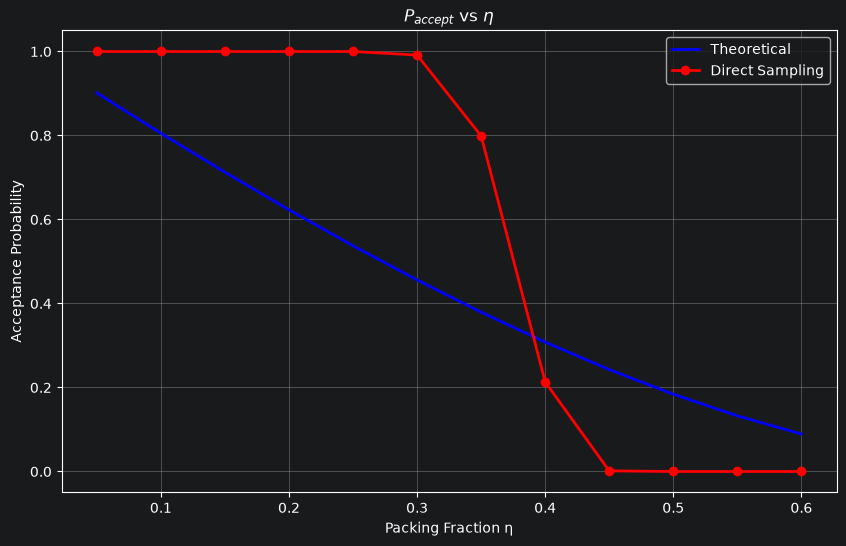

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Density values
eta_values = np.linspace(0.05, 0.6, 12)

# Theoretical values
P_theoretical = []

for eta in eta_values:
    if eta < 0.99:
        P = (1 - eta) * np.exp(-eta / (1 - eta))
    else:
        P = 0
    P_theoretical.append(P)


# Direct Sampling
def DS_accept(eta, n_trials=2000, radius=0.5, box_size=10):

    box_area = box_size**2
    n_disks = int(eta * box_area / (np.pi * radius**2))

    success = 0

    for i in range(n_trials):

        pos = []
        overlap = False

        for j in range(n_disks):

            max_attempts = 50
            placed = False

            for k in range(max_attempts):

                x = np.random.uniform(radius, box_size - radius)
                y = np.random.uniform(radius, box_size - radius)

                overlap = False

                for px, py in pos:

                    dist = np.sqrt((px - x)**2 + (py - y)**2)

                    if dist < 2 * radius:
                        overlap = True
                        break

                if not overlap:
                    pos.append((x, y))
                    placed = True
                    break

            if not placed:
                overlap = True
                break

        if not overlap and len(pos) == n_disks:
            success += 1

    return success / n_trials


#direct sampling values
P_direct = []

for eta in eta_values:

    P = DS_accept(eta)
    P_direct.append(P)
    print(f"η = {eta:.3f}   P_accept = {P:.4f}")




plt.figure(figsize=(10,6))
plt.plot(eta_values, P_theoretical,'b-', linewidth=2,label='Theoretical')
plt.plot(eta_values, P_direct,'ro-', linewidth=2,label='Direct Sampling')

plt.xlabel("Packing Fraction η")
plt.ylabel("Acceptance Probability")
plt.title(r"$P_{accept}$ vs $\eta$")
plt.grid(True)
plt.legend()

plt.show()

# 4) Markov-Chain algorithm for generating the configurations of 4 hard-disks.

Acceptance Rate = 0.7382


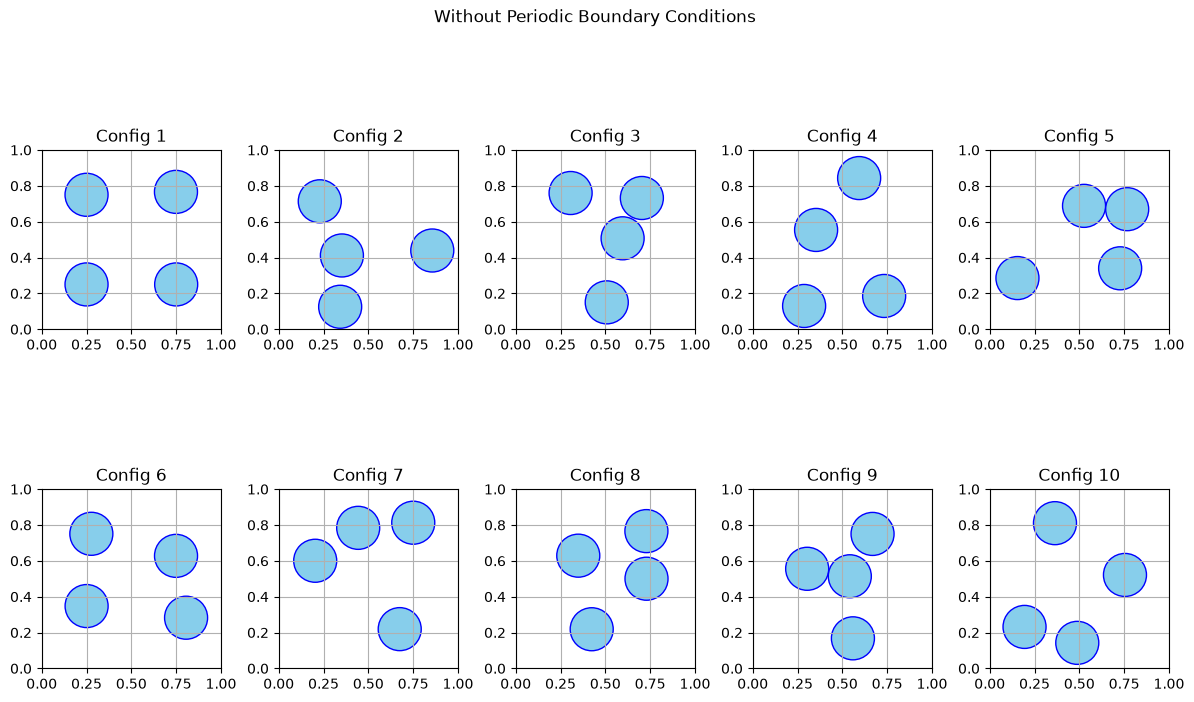

Acceptance Rate = 0.8744


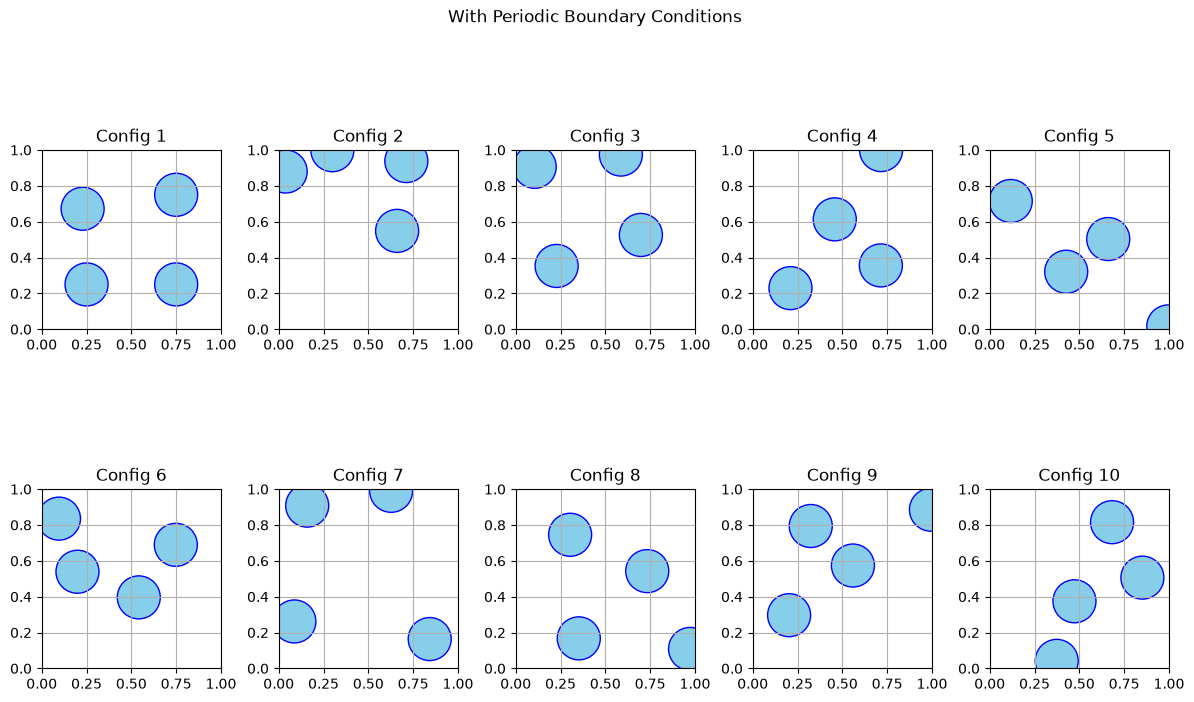

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


class HardDiskMC:

    def __init__(self, n_disks=4, radius=0.12, box=1.0, periodic=False):

        self.n_disks = n_disks
        self.radius = radius
        self.box = box
        self.periodic = periodic
        self.max_move = 0.08

        self.positions = []

        # Initial positions
        n_side = int(np.ceil(np.sqrt(n_disks)))
        spacing = box / n_side

        for i in range(n_side):
            for j in range(n_side):

                if len(self.positions) < n_disks:

                    x = (i + 0.5) * spacing
                    y = (j + 0.5) * spacing

                    self.positions.append([x, y])

        self.saved = []


    def step(self):

        disk = np.random.randint(self.n_disks)

        old = self.positions[disk].copy()

        dx = np.random.uniform(-self.max_move, self.max_move)
        dy = np.random.uniform(-self.max_move, self.max_move)

        newx = old[0] + dx
        newy = old[1] + dy

        if self.periodic:

            newx = newx % self.box
            newy = newy % self.box

        else:

            if newx < self.radius or newx > self.box-self.radius:
                return False

            if newy < self.radius or newy > self.box-self.radius:
                return False

        # Check overlap
        for i in range(self.n_disks):

            if i == disk:
                continue

            x2, y2 = self.positions[i]

            dx = newx - x2
            dy = newy - y2

            if self.periodic:

                dx = dx - self.box*np.round(dx/self.box)
                dy = dy - self.box*np.round(dy/self.box)

            distance = np.sqrt(dx**2 + dy**2)

            if distance < 2*self.radius:
                return False

        self.positions[disk] = [newx, newy]

        return True


    def run(self, steps):

        accept = 0

        for i in range(steps):

            if self.step():
                accept += 1

            if i % 500 == 0:
                self.saved.append([p.copy() for p in self.positions])

        return accept/steps


def plot_configs(configs, radius, box, title):

    plt.figure(figsize=(12,8))

    for i in range(len(configs)):

        plt.subplot(2,5,i+1)

        plt.xlim(0,box)
        plt.ylim(0,box)
        plt.gca().set_aspect('equal')

        for x,y in configs[i]:

            circle = Circle((x,y),radius,facecolor='skyblue',edgecolor='blue')

            plt.gca().add_patch(circle)

        plt.title("Config {}".format(i+1))
        plt.grid(True)

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()


# Without PBC
sim = HardDiskMC(periodic=False)

rate = sim.run(5000)

print("Acceptance Rate =", rate)

plot_configs(sim.saved[:10],sim.radius,sim.box,"Without Periodic Boundary Conditions")


# With PBC

sim = HardDiskMC(periodic=True)

rate = sim.run(5000)

print("Acceptance Rate =", rate)

plot_configs(sim.saved[:10],sim.radius,sim.box,"With Periodic Boundary Conditions")